In [1]:
# %env NX_CUGRAPH_AUTOCONFIG=True

import networkx as nx
import pandas as pd
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

PATH_TO_CONSTANTS = "../../"
#define some constants (file paths)
with open(PATH_TO_CONSTANTS+'constants.json') as f:
    CONSTANTS = json.load(f)



In [2]:
#write graphml Might be faster than 2csvs


nodes_file = PATH_TO_CONSTANTS+CONSTANTS['cleaned_nodes_csv']  # Replace with your nodes CSV file path
edges_file = PATH_TO_CONSTANTS+CONSTANTS['edges_csv']  # Replace with your edges CSV file path
# Load nodes and edges into DataFrames
nodes_df = pd.read_csv(nodes_file)
edges_df = pd.read_csv(edges_file)
edges_df = edges_df[edges_df['type'] != 'has_code'] #drop the has_code stuff

# Create a directed graph
KG = nx.DiGraph()
# Add nodes with attributes
for _, row in tqdm(nodes_df.iterrows()):
    node_id = row['id']  # Replace with the appropriate column name for node ID
    attributes = row.to_dict()
    KG.add_node(node_id, **attributes)    
# Add edges with attributes
for _, row in tqdm(edges_df.iterrows()):
    source = row['source_id']  # Replace with the appropriate column name for source node
    target = row['target_id']  # Replace with the appropriate column name for target node
    attributes = row.to_dict()
    KG.add_edge(source, target, **attributes)
    
    
# graphml_path = PATH_TO_CONSTANTS+CONSTANTS['graphml']

# nx.write_graphml(KG,graphml_path)



88937it [00:07, 12473.58it/s]
816481it [01:03, 12828.82it/s]


In [3]:

graphml_path = PATH_TO_CONSTANTS+CONSTANTS['graphml']
G = nx.read_graphml(graphml_path)

# Assuming G is your graph
nodes_to_remove = [n for n, d in G.nodes(data=True) if pd.isna(d.get('name'))]
G.remove_nodes_from(nodes_to_remove)

In [4]:
G_U = KG.to_undirected(False)

In [5]:
G_U.nodes['GENE:392']

{'Unnamed: 0': 62544,
 'id': 'GENE:392',
 'type': 'gene',
 'properties': '{"PHARMGKB":"PA24572","COMPARATIVE TOXICOGENOMICS DATABASE":"126","ENSEMBL":"ENSG00000248144","GENATLAS":"ADH1C","GENECARD":"ADH1C","HGNC":"HGNC251","MODBASE":"P00326","NCBI GENE":"126","OMIM":"103730;168600","REFSEQ DNA":"NG_011718;NT_016354","REFSEQ PROTEIN":"NP_000660","REFSEQ RNA":"NM_000669","UCSC GENOME BROWSER":"NM_000669","UNIPROTKB":"P00326"}',
 'properties_dict': "{'PHARMGKB': 'PA24572', 'COMPARATIVE TOXICOGENOMICS DATABASE': '126', 'ENSEMBL': 'ENSG00000248144', 'GENATLAS': 'ADH1C', 'GENECARD': 'ADH1C', 'HGNC': 'HGNC251', 'MODBASE': 'P00326', 'NCBI GENE': '126', 'OMIM': '103730;168600', 'REFSEQ DNA': 'NG_011718;NT_016354', 'REFSEQ PROTEIN': 'NP_000660', 'REFSEQ RNA': 'NM_000669', 'UCSC GENOME BROWSER': 'NM_000669', 'UNIPROTKB': 'P00326'}",
 'name': 'alcohol dehydrogenase 1C (class I), gamma polypeptide'}

In [6]:
G_U.edges('COMPOUND:2')

EdgeDataView([('COMPOUND:2', 'PROTEIN:2'), ('COMPOUND:2', 'PROTEIN:3'), ('COMPOUND:2', 'PROTEIN:4'), ('COMPOUND:2', 'PROTEIN:5'), ('COMPOUND:2', 'PROTEIN:6'), ('COMPOUND:2', 'PROTEIN:7'), ('COMPOUND:2', 'PROTEIN:8'), ('COMPOUND:2', 'PROTEIN:9'), ('COMPOUND:2', 'ACTIVITY:2'), ('COMPOUND:2', 'EFFECT:5'), ('COMPOUND:2', 'EFFECT:7'), ('COMPOUND:2', 'EFFECT:8'), ('COMPOUND:2', 'COMPOUND:12843'), ('COMPOUND:2', 'GENE:1090'), ('COMPOUND:2', 'GENE:23587'), ('COMPOUND:2', 'GENE:942'), ('COMPOUND:2', 'GENE:1003'), ('COMPOUND:2', 'GENE:1807'), ('COMPOUND:2', 'GENE:1869'), ('COMPOUND:2', 'GENE:7807'), ('COMPOUND:2', 'GENE:5336'), ('COMPOUND:2', 'GENE:5646'), ('COMPOUND:2', 'GENE:6273'), ('COMPOUND:2', 'GENE:6276'), ('COMPOUND:2', 'GENE:7001'), ('COMPOUND:2', 'GENE:16761'), ('COMPOUND:2', 'GENE:4224'), ('COMPOUND:2', 'GENE:9867'), ('COMPOUND:2', 'GENE:10143'), ('COMPOUND:2', 'GENE:11267'), ('COMPOUND:2', 'GENE:13640'), ('COMPOUND:2', 'GENE:13649'), ('COMPOUND:2', 'GENE:13650'), ('COMPOUND:2', 'GENE

In [7]:
tmp =G_U.subgraph(['PROTEIN:6046', 'COMPOUND:31101', 'PROTEIN:6014' ])
tmp.edges

EdgeView([('COMPOUND:31101', 'PROTEIN:6046'), ('COMPOUND:31101', 'PROTEIN:6014')])

In [8]:
len(G_U.nodes), len(G_U.edges)

(88937, 653710)

In [18]:
len(KG.nodes), len(KG.edges)

(88937, 783378)

In [10]:
len(nodes_to_remove)

3282

In [16]:
len(G.nodes)
# len(G.edges)

85655

In [20]:
# reduce the size of the graph (optional)

nodes_to_remove = [node for node, degree in G.degree() if degree > 100 or degree < 3]
red_KG = G.copy()
red_KG.remove_nodes_from(nodes_to_remove)
# red_KG = nx.k_core(red_KG, 3) # contains subgraphs of atleast 3 or more




In [22]:
len(nodes_to_remove)

44970

In [21]:
len(red_KG.nodes), len(red_KG.edges)

(40685, 125809)

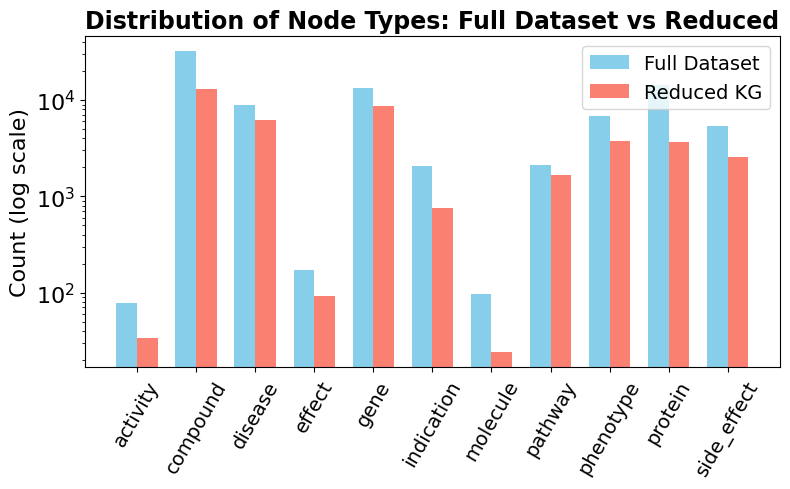

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Calculate type counts for both datasets
type_counts_full = Counter(data.get('type') for _, data in G.nodes(data=True))
type_counts_reduced = Counter(data.get('type') for _, data in red_KG.nodes(data=True))

# Get the union of all types from both datasets
all_types = sorted(set(type_counts_full.keys()).union(type_counts_reduced.keys()))

# Prepare counts for each type (defaulting to 0 if a type is missing in one dataset)
full_counts = [type_counts_full.get(t, 0) for t in all_types]
reduced_counts = [type_counts_reduced.get(t, 0) for t in all_types]

# Set up the grouped bar chart
x = np.arange(len(all_types))
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8, 5))
bars_full = ax.bar(x - width/2, full_counts, width, label='Full Dataset', color='skyblue')
bars_reduced = ax.bar(x + width/2, reduced_counts, width, label='Reduced KG', color='salmon')

# Add labels and title with specified font sizes
ax.set_ylabel('Count (log scale)', fontsize=16)
ax.set_title('Distribution of Node Types: Full Dataset vs Reduced', fontsize=17, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=60, fontsize=14)

# Set tick label sizes for y-axis as well
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize=14)

# Set logarithmic scale for y-axis
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"Node_Distribution_red.pdf", format='pdf', dpi=300)  # Export with high resolution
plt.show()


In [9]:
type_counts_reduced

Counter({'disease': 5372,
         'gene': 4940,
         'phenotype': 3718,
         'compound': 2385,
         'protein': 1560,
         'pathway': 1509,
         'side_effect': 333,
         'indication': 91,
         'effect': 52,
         'activity': 20,
         'molecule': 3})

In [10]:
len(red_KG.edges)

109868

In [31]:
degrees = [val for (node, val) in red_KG.degree()]
degree_count = Counter(degrees)
# sorted(degree_count)
# def

In [32]:
degree_count

Counter({0: 9840,
         1: 5142,
         2: 4584,
         3: 4327,
         4: 2789,
         5: 2082,
         6: 1453,
         7: 1317,
         8: 1017,
         9: 827,
         10: 729,
         11: 620,
         12: 476,
         13: 425,
         14: 398,
         15: 383,
         16: 321,
         17: 288,
         18: 242,
         19: 234,
         20: 226,
         22: 202,
         21: 196,
         23: 172,
         24: 142,
         25: 142,
         26: 132,
         28: 112,
         27: 112,
         29: 99,
         32: 91,
         30: 88,
         33: 79,
         34: 78,
         35: 77,
         36: 76,
         31: 69,
         39: 62,
         37: 51,
         38: 51,
         56: 48,
         41: 47,
         40: 47,
         47: 42,
         53: 40,
         52: 40,
         42: 39,
         45: 35,
         44: 35,
         46: 33,
         51: 32,
         48: 28,
         50: 28,
         43: 26,
         49: 26,
         54: 25,
         60: 21,
   

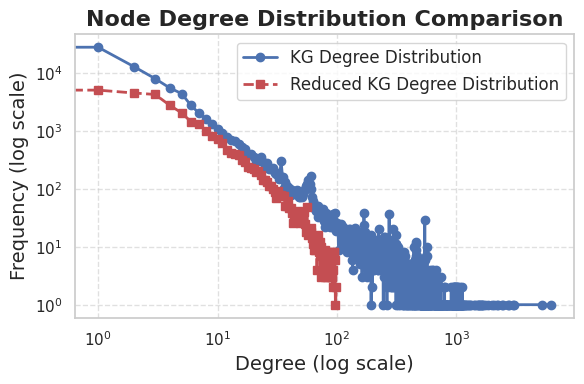

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter

# Apply seaborn theme
sns.set(style="whitegrid")

def get_degree_distribution(graph):
    """Returns sorted degrees and their corresponding frequencies."""
    degrees = [val for (node, val) in graph.degree()]
    degree_count = Counter(degrees)
    degree_values = sorted(degree_count.keys())
    frequencies = [degree_count[degree] for degree in degree_values]
    return degree_values, frequencies

# Get degree distributions
deg_values_G, freq_G = get_degree_distribution(G)
deg_values_red, freq_red = get_degree_distribution(red_KG)

# Create the plot
plt.figure(figsize=(6, 4))

# Plot both degree distributions
plt.plot(deg_values_G, freq_G, marker='o', linestyle='-', color='b', 
         markersize=6, linewidth=2, label='KG Degree Distribution')
plt.plot(deg_values_red, freq_red, marker='s', linestyle='--', color='r', 
         markersize=6, linewidth=2, label='Reduced KG Degree Distribution')

# Log-log scale for better visualization
plt.xscale('log')
plt.yscale('log')

# Labels, title, and legend
plt.xlabel('Degree (log scale)', fontsize=14)
plt.ylabel('Frequency (log scale)', fontsize=14)
plt.title('Node Degree Distribution Comparison', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save and show the plot
plt.savefig(PATH_TO_CONSTANTS + CONSTANTS['figures'] + "Degree_Distribution.pdf", 
            format='pdf', dpi=300)
plt.show()
